In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



In [4]:
teams = pd.read_csv("Teams.csv")
#sal = salaries
sal = pd.read_csv("Salaries.csv")

In [7]:
#Checks to confirm data size(mainly to see if importing file correctly)
print("Teams size:", teams.shape)
print("Salaries size:", sal.shape)

Teams size: (2805, 48)
Salaries size: (25575, 5)


In [8]:
#Prints dataset for teams
teams.head()

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,1871,NaN,BS1,BNA,NaN,3,31,NaN,20,10,...,NaN,0.83,Boston Red Stockings,South End Grounds I,NaN,103,98,BOS,BS1,BS1
1,1871,NaN,CH1,CNA,NaN,2,28,NaN,19,9,...,NaN,0.82,Chicago White Stockings,Union Base-Ball Grounds,NaN,104,102,CHI,CH1,CH1
2,1871,NaN,CL1,CFC,NaN,8,29,NaN,10,19,...,NaN,0.81,Cleveland Forest Citys,National Association Grounds,NaN,96,100,CLE,CL1,CL1
3,1871,NaN,FW1,KEK,NaN,7,19,NaN,7,12,...,NaN,0.80,Fort Wayne Kekiongas,Hamilton Field,NaN,101,107,KEK,FW1,FW1
4,1871,NaN,NY2,NNA,NaN,5,33,NaN,16,17,...,NaN,0.83,New York Mutuals,Union Grounds (Brooklyn),NaN,90,88,NYU,NY2,NY2


In [9]:
#Prints dataset for salaries
sal.head()

,yearID,teamID,lgID,playerID,salary
0,1985,ATL,NL,barkele01,870000
1,1985,ATL,NL,bedrost01,550000
2,1985,ATL,NL,benedbr01,545000
3,1985,ATL,NL,campri01,633333
4,1985,ATL,NL,ceronri01,625000


In [10]:
print(teams.columns.tolist())

['yearID', 'lgID', 'teamID', 'franchID', 'divID', 'Rank', 'G', 'Ghome', 'W', 'L', 'DivWin', 'WCWin', 'LgWin', 'WSWin', 'R', 'AB', 'H', '2B', '3B', 'HR', 'BB', 'SO', 'SB', 'CS', 'HBP', 'SF', 'RA', 'ER', 'ERA', 'CG', 'SHO', 'SV', 'IPouts', 'HA', 'HRA', 'BBA', 'SOA', 'E', 'DP', 'FP', 'name', 'park', 'attendance', 'BPF', 'PPF', 'teamIDBR', 'teamIDlahman45', 'teamIDretro']


In [11]:
print(sal.columns.tolist())

['yearID', 'teamID', 'lgID', 'playerID', 'salary']


In [12]:
teampay = sal.groupby(["yearID", "teamID"])["salary"].sum().reset_index()
teampay.head()

,yearID,teamID,salary
0,1985,ATL,14807000
1,1985,BAL,11560712
2,1985,BOS,10897560
3,1985,CAL,14427894
4,1985,CHA,9846178


In [13]:
print("Teampay size: ",teampay.shape)

Teampay size:  (888, 3)


In [14]:
teamsShrunk = teams[["yearID", "teamID", "W", "L", "R", "RA", "ERA"]].copy()
teamsShrunk.head()

,yearID,teamID,W,L,R,RA,ERA
0,1871,BS1,20,10,401,303,3.55
1,1871,CH1,19,9,302,241,2.76
2,1871,CL1,10,19,249,341,4.11
3,1871,FW1,7,12,137,243,5.17
4,1871,NY2,16,17,302,313,3.72


In [15]:
df = pd.merge(teamsShrunk, teampay, on=["yearID", "teamID"], how = "inner")
print("Merged size: ", df.shape)
df.head()

Merged size:  (888, 8)


,yearID,teamID,W,L,R,RA,ERA,salary
0,1985,ATL,66,96,632,781,4.19,14807000
1,1985,BAL,83,78,818,764,4.38,11560712
2,1985,BOS,81,81,800,720,4.06,10897560
3,1985,CAL,90,72,732,703,3.91,14427894
4,1985,CHA,85,77,736,720,4.07,9846178


In [16]:
df["run_diff"] = df["R"] - df["RA"]
df.head()

,yearID,teamID,W,L,R,RA,ERA,salary,run_diff
0,1985,ATL,66,96,632,781,4.19,14807000,-149
1,1985,BAL,83,78,818,764,4.38,11560712,54
2,1985,BOS,81,81,800,720,4.06,10897560,80
3,1985,CAL,90,72,732,703,3.91,14427894,29
4,1985,CHA,85,77,736,720,4.07,9846178,16


In [17]:
df.isnull().sum()

yearID      0
teamID      0
W           0
L           0
R           0
RA          0
ERA         0
salary      0
run_diff    0
dtype: int64

In [18]:
df.duplicated().sum()

0

In [20]:
df = df[df["yearID"] >= 1990]
print(df.shape)

(758, 9)


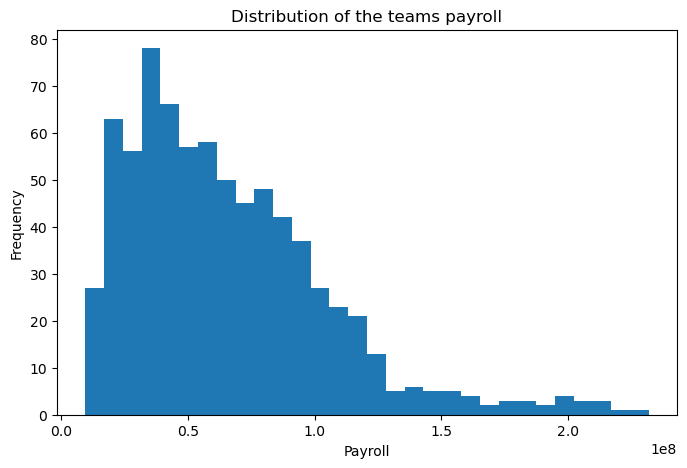

In [25]:
plt.figure(figsize = (8,5))
plt.hist(df["salary"], bins=30)
plt.title("Distribution of the teams payroll")
plt.xlabel("Payroll")
plt.ylabel("Frequency")
plt.show()

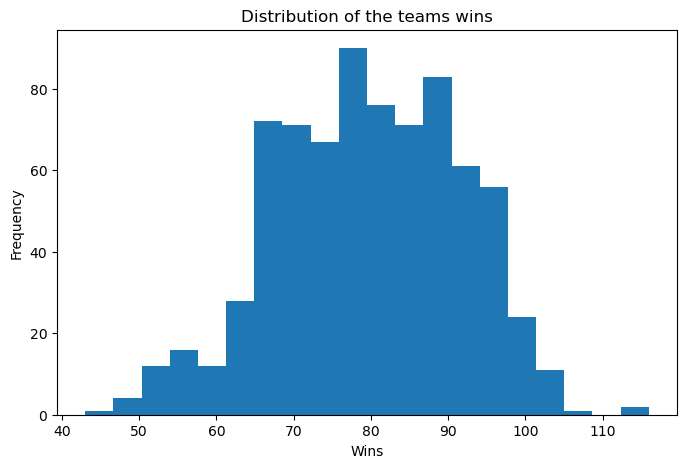

In [26]:
plt.figure(figsize = (8,5))
plt.hist(df["W"], bins=20)
plt.title("Distribution of the teams wins")
plt.xlabel("Wins")
plt.ylabel("Frequency")
plt.show()

In [32]:
df["payroll_mil"] = df["salary"]/1000000

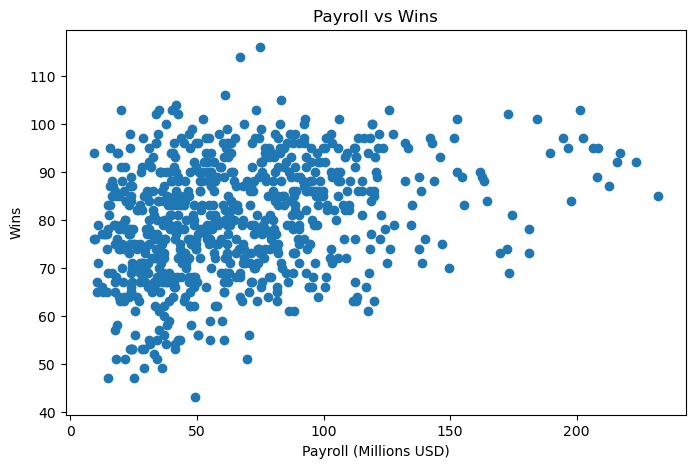

In [33]:
plt.figure(figsize = (8,5))
plt.scatter(df["payroll_mil"], df["W"])
plt.title("Payroll vs Wins")
plt.xlabel("Payroll (Millions USD)")
plt.ylabel("Wins")
plt.show()

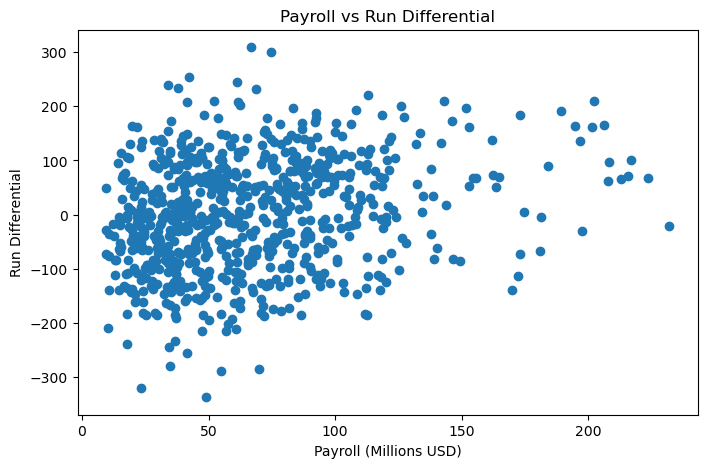

In [34]:
plt.figure(figsize = (8,5))
plt.scatter(df["payroll_mil"], df["run_diff"])
plt.title("Payroll vs Run Differential")
plt.xlabel("Payroll (Millions USD)")
plt.ylabel("Run Differential")
plt.show()

In [35]:
df[["salary", "W", "L", "ERA", "run_diff"]].corr()

,salary,W,L,ERA,run_diff
salary,1.000000,0.314511,-0.149147,-0.196417,0.246811
W,0.314511,1.000000,-0.688389,-0.566182,0.857643
L,-0.149147,-0.688389,1.000000,0.480119,-0.856844
ERA,-0.196417,-0.566182,0.480119,1.000000,-0.593661
run_diff,0.246811,0.857643,-0.856844,-0.593661,1.000000


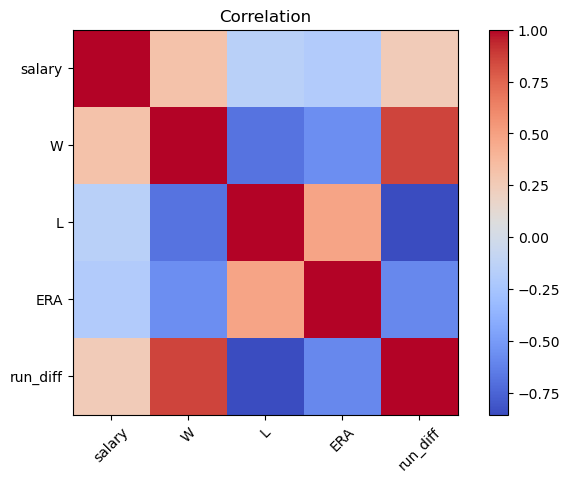

In [37]:
plt.figure(figsize = (8,5))
plt.imshow(df[["salary", "W", "L", "ERA", "run_diff"]].corr(), cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.title("Correlation")
plt.xticks(range(5), ["salary", "W", "L", "ERA", "run_diff"], rotation=45)
plt.yticks(range(5), ["salary", "W", "L", "ERA", "run_diff"])
plt.show()

In [38]:
features = df[["salary", "W","ERA", "run_diff"]]
features.head()

,salary,W,ERA,run_diff
130,14555501,65,4.58,-139
131,9680084,76,4.04,-29
132,20558333,88,3.72,35
133,21720000,80,3.79,-16
134,9491500,94,3.61,49


In [39]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [42]:
inertia =[]
for k in range(1,10):
    model = KMeans(n_clusters=k,random_state =42, n_init=10)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

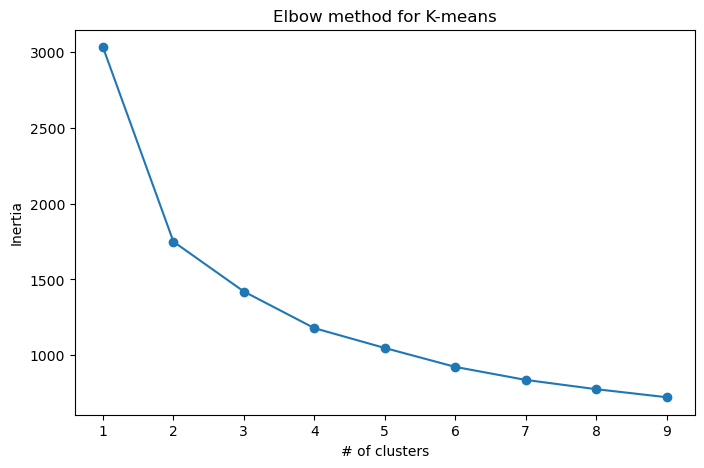

In [43]:
plt.figure(figsize = (8,5))
plt.plot(range(1,10), inertia, marker="o")
plt.title("Elbow method for K-means")
plt.xlabel("# of clusters")
plt.ylabel("Inertia")
plt.show()

In [44]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(scaled_data)

C:\Users\Brett\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [50]:
df.head()

,yearID,teamID,W,L,R,RA,ERA,salary,run_diff,payroll_mil,cluster
130,1990,ATL,65,97,682,821,4.58,14555501,-139,14.555501,1
131,1990,BAL,76,85,669,698,4.04,9680084,-29,9.680084,2
132,1990,BOS,88,74,699,664,3.72,20558333,35,20.558333,2
133,1990,CAL,80,82,690,706,3.79,21720000,-16,21.720000,2
134,1990,CHA,94,68,682,633,3.61,9491500,49,9.491500,2


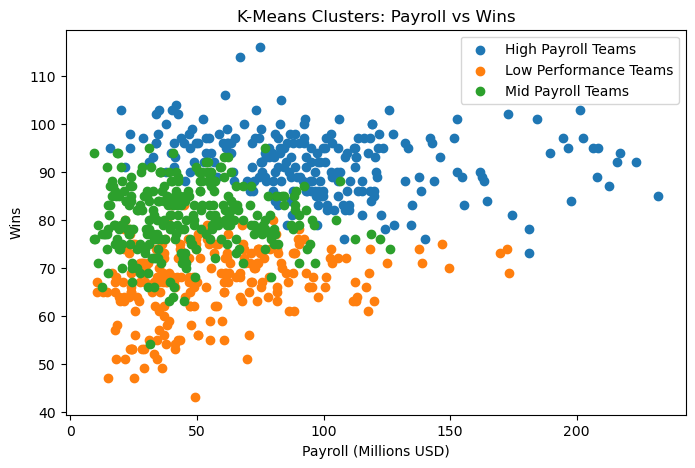

In [54]:
plt.figure(figsize = (8,5))

cluster_labels = {
    0:"High Payroll Teams",
    1:"Low Performance Teams",
    2:"Mid Payroll Teams"
}
for cluster_num in sorted(df["cluster"].unique()):
    cluster_data = df[df["cluster"] == cluster_num]
    plt.scatter(cluster_data["payroll_mil"], cluster_data["W"], label=cluster_labels[cluster_num])

plt.title("K-Means Clusters: Payroll vs Wins")
plt.xlabel("Payroll (Millions USD)")
plt.ylabel("Wins")
plt.legend()
plt.show()

In [49]:
df.groupby("cluster")[["salary", "W", "ERA", "run_diff"]].mean()

,salary,W,ERA,run_diff
cluster,,,,
0,9.735629e+07,91.928270,3.817637,99.421941
1,5.670018e+07,67.106996,4.777490,-111.115226
2,4.681501e+07,80.424460,4.175468,12.366906
